# 1. Project Title: 

### Loan Default Prediction using Machine Learning : 
This project builds a predictive model to identify borrowers likely to default using financial and credit-related features.

# 2. Problem Statement:

## Business Objective : 
+ The objective of this project is to build a predictive model that identifies borrowers who are likely to default on their loans using financial and credit-related features. This helps financial institutions make data-driven lending decisions and manage credit risk effectively.

## Why Default Prediction Matters:

+ Loan defaults result in significant financial losses for banks and lending institutions. Accurately identifying high-risk borrowers enables better risk management, optimized approval strategies, and improved profitability while maintaining responsible lending practices.

## Imbalanced Classification Problem

+ In this dataset, the number of non-defaulters significantly exceeds defaulters, making it an imbalanced classification problem. Special attention is given to recall and ROC-AUC rather than overall accuracy to ensure the model effectively detects risky borrowers.

# 3. Data Loading : 

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

+ The dataset is loaded and initial inspection is performed to understand its structure and dimensions.

In [2]:
#Importing Dataset
df = pd.read_csv(
    "LoanDataset.csv.gz",
    compression='gzip',
    encoding='ISO-8859-1',
    low_memory=False
)

In [3]:
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(2260701, 151)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [6]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [7]:
#Checking Unique Values in Target column 
df['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

# 4. Traget Cleaning: 


+ The target variable is filtered to retain only completed loan outcomes and converted into binary format (0 = Fully Paid, 1 = Default).

In [8]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

df['loan_status'].value_counts()

loan_status
0    1076751
1     268559
Name: count, dtype: int64

# 5. Feature Selection: 

+ Key variables are cleaned and transformed. Derived features such as FICO score are created to improve model performance.

In [9]:
useful_columns = [
    'loan_amnt',
    'funded_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'addr_state',
    'dti',
    'fico_range_low',
    'fico_range_high',
    'open_acc',
    'revol_bal',
    'revol_util',
    'loan_status'
]

In [10]:
df = df[useful_columns]

In [11]:
df.shape 

(1345310, 20)

# 6. Missing Value Handling :
## A) Showing Missing % :

In [12]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

emp_length             5.835904
revol_util             0.063703
dti                    0.027800
loan_amnt              0.000000
purpose                0.000000
revol_bal              0.000000
open_acc               0.000000
fico_range_high        0.000000
fico_range_low         0.000000
addr_state             0.000000
verification_status    0.000000
funded_amnt            0.000000
annual_inc             0.000000
home_ownership         0.000000
sub_grade              0.000000
grade                  0.000000
installment            0.000000
int_rate               0.000000
term                   0.000000
loan_status            0.000000
dtype: float64

## B). Handle Missing Values: 
+ Missing values are analyzed and handled appropriately to ensure model stability and avoid data loss.

In [13]:
# Fill numeric columns with median 
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())

#Fill emp_length with 'Unknown' 
df['emp_length'] = df['emp_length'].fillna('Unknown') 

In [14]:
df.isnull().sum()

loan_amnt              0
funded_amnt            0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
addr_state             0
dti                    0
fico_range_low         0
fico_range_high        0
open_acc               0
revol_bal              0
revol_util             0
loan_status            0
dtype: int64

## 7. Feature Engineering: 
+ Key variables are cleaned and transformed. Derived features such as FICO score are created to improve model performance.

## A) Clean 'term':

In [15]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [16]:
df['term'] = df['term'].str.strip()         #remove leading spaces
df['term'] = df['term'].str.replace(' months','') 
df['term'] = df['term'].astype(int) 

In [17]:
df['term'].unique()

array([36, 60])

## B) Clean 'emp_length':

In [18]:
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', 'Unknown'],
      dtype=object)

In [19]:
#Replace Special Cases  
df['emp_length'] = df['emp_length'].replace({
    '10+ years' : '10',
    '< 1 year' : '0', 
    'Unknown' : None
}) 

#Remove text  
df['emp_length'] = df['emp_length'].str.replace(' years','',regex=False)
df['emp_length'] = df['emp_length'].str.replace(' year','',regex=False)

#Convert to float 
df['emp_length'] = df['emp_length'].astype(float) 

#Fill Missing Values (from Unknown) with Median 
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median()) 

In [20]:
df['emp_length'].unique()

array([10.,  3.,  4.,  6.,  7.,  8.,  2.,  5.,  9.,  0.,  1.])

## C). Creating Average Fico Score Feature  & Drop Redundant Columns

In [21]:
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high'])/2 

#Drop old columns 
df.drop(['fico_range_low','fico_range_high'], axis=1,inplace=True) 

In [22]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,open_acc,revol_bal,revol_util,loan_status,fico_score
0,3600.0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,7.0,2765.0,29.7,0,677.0
1,24700.0,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,22.0,21470.0,19.2,0,717.0
2,20000.0,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,6.0,7869.0,56.2,0,697.0
4,10400.0,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,12.0,21929.0,64.5,0,697.0
5,11950.0,11950.0,36,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,5.0,8822.0,68.4,0,692.0


In [23]:
df.shape

(1345310, 19)

# 8. Encoding: 

## A) Identify Categorical Columns 

In [24]:
df.dtypes

loan_amnt              float64
funded_amnt            float64
term                     int32
int_rate               float64
installment            float64
grade                   object
sub_grade               object
emp_length             float64
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
addr_state              object
dti                    float64
open_acc               float64
revol_bal              float64
revol_util             float64
loan_status              int64
fico_score             float64
dtype: object

+ grade and sub_grade are highly correlated.
+ sub_grade already contains grade information (A1, A2, B3…).
+ drop sub_grade and keep grade

### B) Drop sub_grade

In [25]:
df = df.drop('sub_grade',axis=1)

In [26]:
df.shape

(1345310, 18)

## C) Encode grade (Ordinal :
+ The grade variable was ordinally encoded to preserve its natural ranking (A–G), allowing the model to interpret higher grades as progressively higher risk.

In [27]:
grade_mapping = {
    'A' : 1, 
    'B' : 2, 
    'C' : 3, 
    'D' : 4, 
    'E' : 5, 
    'F' : 6, 
    'G' : 7
} 

df['grade'] = df['grade'].map(grade_mapping) 

In [28]:
df['grade'].unique()

array([3, 2, 6, 1, 5, 4, 7], dtype=int64)

## D) One-Hot Encode Nominal Columns (Encoding Categorical Variables) : 
+ Categorical features are encoded using appropriate techniques to make them suitable for machine learning algorithms.

In [29]:
categorical_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state'
] 

df_encoded  = pd.get_dummies(df,columns=categorical_cols, drop_first=True) 


In [30]:
df_encoded.shape

(1345310, 84)

# 9.Data Splitting: 

X -> Features 

y -> Target

In [31]:
X = df_encoded.drop('loan_status',axis=1)
y = df_encoded['loan_status'] 

In [32]:
X.shape, y.shape

((1345310, 83), (1345310,))

## A) Train-Test Split: 
+ The dataset is split into training and testing sets using stratified sampling to preserve class distribution.

In [33]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test  = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
X_train.shape, X_test.shape

((1076248, 83), (269062, 83))

# 10. Scaling (Standardization) : 
+ Numerical features are standardized to improve the performance of Logistic Regression.

In [35]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [36]:
X_train_scaled.shape

(1076248, 83)

# 11. Logistic Regression Model : 

## A) Why Logitstic Regression Model is Used ?

+ It’s simple

+ Interpretable

+ Strong baseline for classification

+ Very common in credit risk

## B) Train - Model : 
+ A baseline Logistic Regression model is trained and evaluated using classification metrics and ROC-AUC.

In [37]:
from sklearn.linear_model import LogisticRegression 

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [38]:
# Train the model 
log_model.fit(X_train_scaled, y_train) 

LogisticRegression(class_weight='balanced', max_iter=1000)

## C) Predictions:

1. Make Predictions: 

In [39]:
y_pred = log_model.predict(X_test_scaled)

In [40]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

In [41]:
y_pred.shape

(269062,)

2. Get Probabilities : 

In [42]:
y_proba = log_model.predict_proba(X_test_scaled)[:,1]

In [43]:
y_proba[:10]

array([0.34424512, 0.32669909, 0.37160834, 0.39592498, 0.49049331,
       0.48132075, 0.65001002, 0.28841622, 0.325209  , 0.57159304])

## D) Model Evaluation: 

In [44]:
from sklearn.metrics import classification_report, roc_auc_score 

#Classification Report
print(classification_report(y_test,y_pred)) 

#ROC-AUC 
roc_auc =  roc_auc_score(y_test,y_proba) 
print(f'ROC-AUC Score: {roc_auc}.')

              precision    recall  f1-score   support

           0       0.88      0.66      0.76    215350
           1       0.32      0.64      0.43     53712

    accuracy                           0.66    269062
   macro avg       0.60      0.65      0.59    269062
weighted avg       0.77      0.66      0.69    269062

ROC-AUC Score: 0.7082692228686887.


# 12. Random Forest Model : 

## A) Why Random Forest Model is used ?  

+ Captures non-linear relationships

+ Handles complex feature interactions automatically

+ Robust to noise and overfitting

+ Works well with large datasets

## B) Train- Model : 
+ A Random Forest classifier is trained and evaluated using classification metrics and ROC-AUC to compare its performance against the baseline model.

In [45]:
from sklearn.ensemble import RandomForestClassifier 

rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42, 
    class_weight = 'balanced', 
    n_jobs = -1
) 

In [46]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

## C) Predictions: 

1) Make Predictions:

In [47]:
rf_y_pred =  rf_model.predict(X_test)

2) Get Probabilities : 

In [48]:
rf_y_proba = rf_model.predict_proba(X_test)[:,1] 

## D) Model Evaluation:

In [49]:
# Classification Report 
print(classification_report(y_test,rf_y_pred))

#ROC-AUC 
roc_auc =  roc_auc_score(y_test,rf_y_proba) 
print(f'ROC-AUC Score: {roc_auc}.')

              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215350
           1       0.54      0.07      0.12     53712

    accuracy                           0.80    269062
   macro avg       0.67      0.53      0.50    269062
weighted avg       0.76      0.80      0.74    269062

ROC-AUC Score: 0.7041483108944373.


# 13. Model Comparison: 

Both Logistic Regression and Random Forest were evaluated using Precision, Recall, F1-score, and ROC-AUC.

+ Logistic Regression

    + ROC-AUC: 0.708

    + Recall (Default): 0.64

    + Precision (Default): 0.32

    + Accuracy: 0.66

+ Random Forest

    + ROC-AUC: 0.704

    + Recall (Default): 0.07

    + Precision (Default): 0.54

    + Accuracy: 0.80

Although Random Forest achieved higher accuracy, it failed to detect defaulters effectively (recall = 7%). Logistic Regression performed significantly better at identifying risky borrowers. Since detecting defaulters is critical in credit risk modeling, Logistic Regression is selected as the preferred baseline model.

# 14 . Cross-Validation Analysis : 
+ 5-fold cross-validation was performed to evaluate model stability. The average ROC-AUC remained consistent, indicating that the model generalizes well across different data splits.

In [56]:
from sklearn.model_selection import cross_val_score 

cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train, 
    cv = 5, 
    scoring = 'roc_auc'
) 

print(f'Cross-Validation ROC-AUC Scores: {cv_scores}.')
print(f'Mean ROC-AUC:{cv_scores.mean()}')
print(f'Standard Deviation : {cv_scores.std()}.')

Cross-Validation ROC-AUC Scores: [0.70451599 0.70944174 0.71120944 0.70764148 0.70893477].
Mean ROC-AUC:0.7083486830964398
Standard Deviation : 0.0022321248536451817.


# 14.Threshold Tuning (Logistic Regression): 

In [50]:
threshold = 0.45

y_pred_045 = (y_proba >= threshold).astype(int) 

print(f'Threshold : {threshold}.')
print(classification_report(y_test,y_pred_045))

Threshold : 0.45.
              precision    recall  f1-score   support

           0       0.89      0.56      0.69    215350
           1       0.29      0.73      0.42     53712

    accuracy                           0.60    269062
   macro avg       0.59      0.65      0.56    269062
weighted avg       0.77      0.60      0.64    269062



+ Multiple thresholds were tested (0.35–0.5) to balance recall and precision. Threshold 0.45 provided the best trade-off and was selected as the final decision boundary.

# 15. ROC Curve Visualization

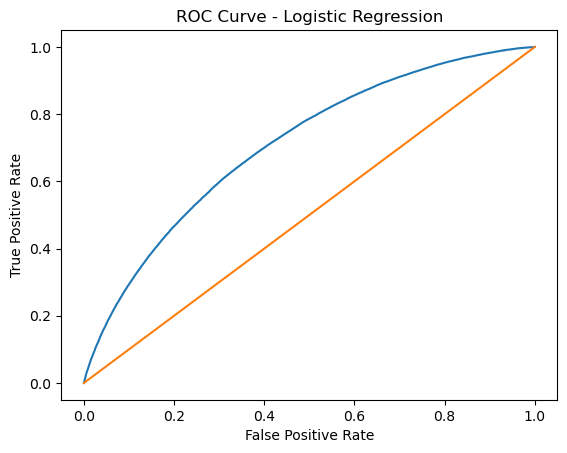

In [51]:
from sklearn.metrics import roc_curve 

#Calculate ROC Values 
fpr, tpr, thresholds = roc_curve(y_test,y_proba) 
roc_auc = roc_auc_score(y_test,y_proba) 

# Plot ROC Curve 
plt.figure() 
plt.plot(fpr, tpr) 
plt.plot([0,1],[0,1]) 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("ROC Curve - Logistic Regression") 
plt.show() 

+ The ROC curve illustrates the trade-off between True Positive Rate and False Positive Rate across different thresholds. The model achieves a ROC-AUC score of approximately 0.71, indicating decent discriminatory power in distinguishing defaulters from non-defaulters.

# 16. Feature Importance (Logistic Regression): 

In [52]:
# Get Features names  
feature_names = X.columns 

# Get Coefficients 
coefficients = log_model.coef_[0]

#Create dataframe 
feature_importance = pd.DataFrame({
    "Feature" : feature_names,
    "Coefficient" : coefficients
})

#Sort by absolute importance  
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("Abs_Coefficient",ascending=False)

In [53]:
feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
2,term,0.257928,0.257928
5,grade,0.248861,0.248861
12,fico_score,-0.215179,0.215179
3,int_rate,0.181029,0.181029
8,dti,0.174294,0.174294
4,installment,0.131266,0.131266
7,annual_inc,-0.117907,0.117907
13,home_ownership_MORTGAGE,-0.088093,0.088093
17,home_ownership_RENT,0.088031,0.088031
18,verification_status_Source Verified,0.075275,0.075275


#### Feature Importance Analysis:

+ The most influential features include loan term, credit grade, FICO score, interest rate, and debt-to-income ratio. Longer loan terms, lower credit grades, higher interest rates, and higher DTI increase default probability, while higher FICO scores and higher annual income reduce risk. The model’s feature importance aligns with financial risk principles, indicating logical and interpretable behavior.

# 17. Final Project Conclusion : 

+ This project aimed to predict loan default using borrower financial and credit-related features. After data cleaning, feature engineering, and model training, both Logistic Regression and Random Forest were evaluated.

+ Although Random Forest achieved higher overall accuracy, it failed to detect defaulters effectively. Logistic Regression achieved a ROC-AUC of 0.71 and demonstrated significantly better recall for the default class.

+ After threshold tuning, a decision threshold of 0.45 was selected, improving recall to 73% while maintaining reasonable precision. Feature importance analysis confirmed that key financial indicators such as loan term, credit grade, FICO score, interest rate, and debt-to-income ratio strongly influence default risk.

+ Overall, Logistic Regression with threshold tuning was selected as the final model due to its balanced performance and interpretability, making it suitable for credit risk modeling.

+ The model demonstrates stable performance across multiple folds, indicating robustness.